In [13]:
import pandas as pd
import chardet
import matplotlib.pyplot as plt
import numpy as np
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

In [14]:
# Функция для загрузки одного файла
def load_csv(file_path, decimal='.'):
    # Определяем кодировку
    with open(file_path, 'rb') as f:
        encoding = chardet.detect(f.read())['encoding']
    
    # Загружаем файл
    df = pd.read_csv(file_path, encoding=encoding, sep=';', decimal=decimal)
    return df

In [15]:
# Загружаем все 5 файлов
df1 = load_csv('data/1.csv')
df2 = load_csv('data/2.csv')
df3 = load_csv('data/3.csv', decimal=',')
df4 = load_csv('data/4.csv')
df5 = load_csv('data/5.csv')

# Удаляем пустой столбец из df3
df3.drop(df3.columns[40], axis=1, inplace=True)

df2.columns = [i[3:] for i in df2.columns]
df4.columns = [i[3:] for i in df4.columns]
df5.columns = [i[3:] for i in df5.columns]

dfs = [df1, df2, df4, df3, df5]

In [16]:
for df in dfs:
    print(df.shape)

(12659, 24)
(13720, 24)
(13743, 24)
(14896, 40)
(38089, 24)


In [17]:
# Приводим столбец времени к одному названию "t" и переводим время в python-объект для удобной работы
for df in dfs:
    cols = df.columns.tolist()
    cols[0] = 't'
    df.columns = cols
    df['t'] = pd.to_datetime(df["t"], format='%H:%M:%S.%f').dt.time

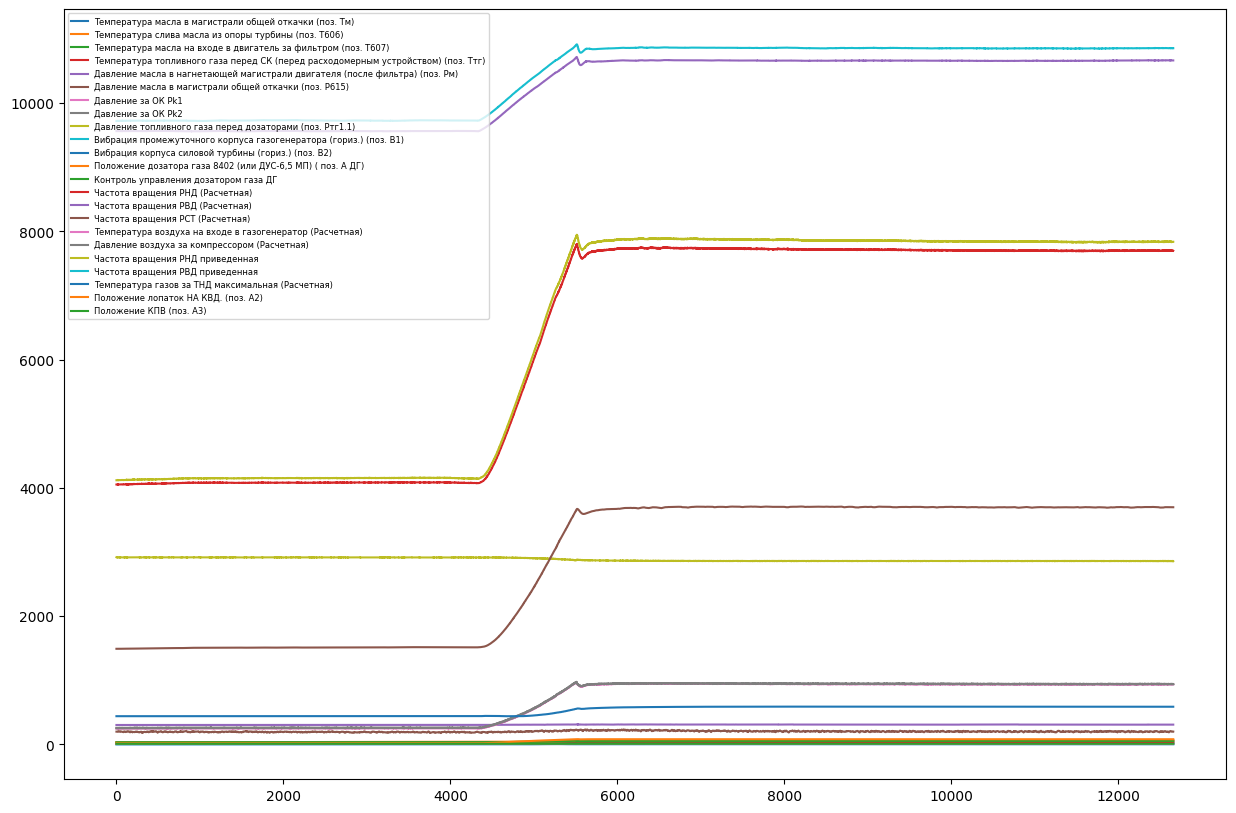

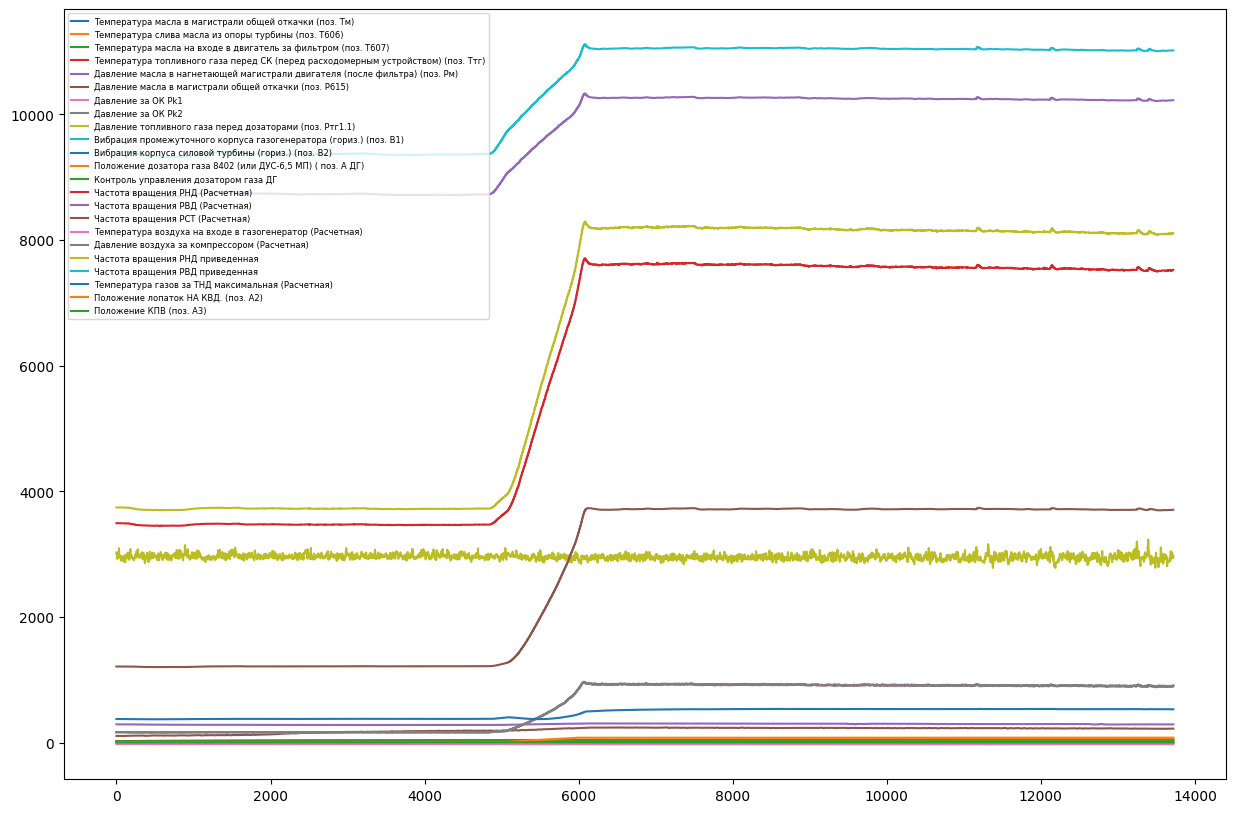

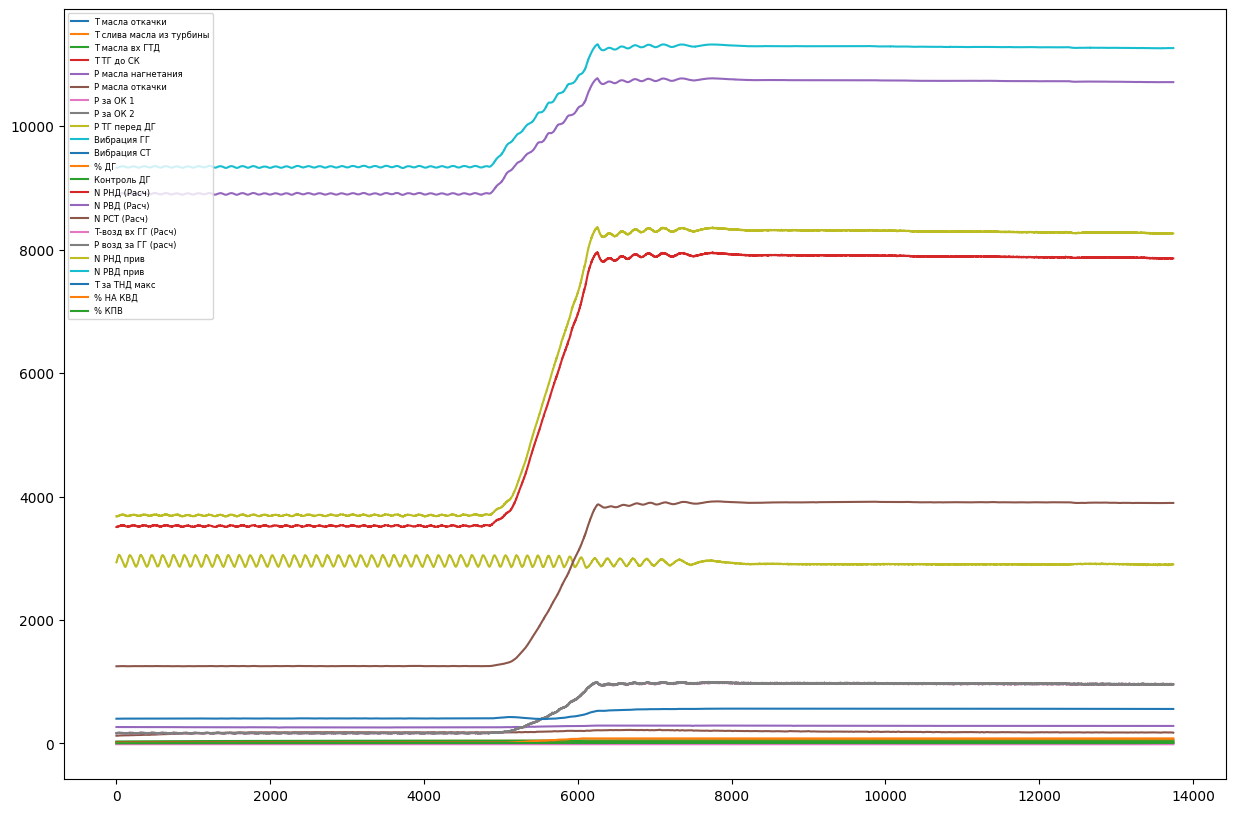

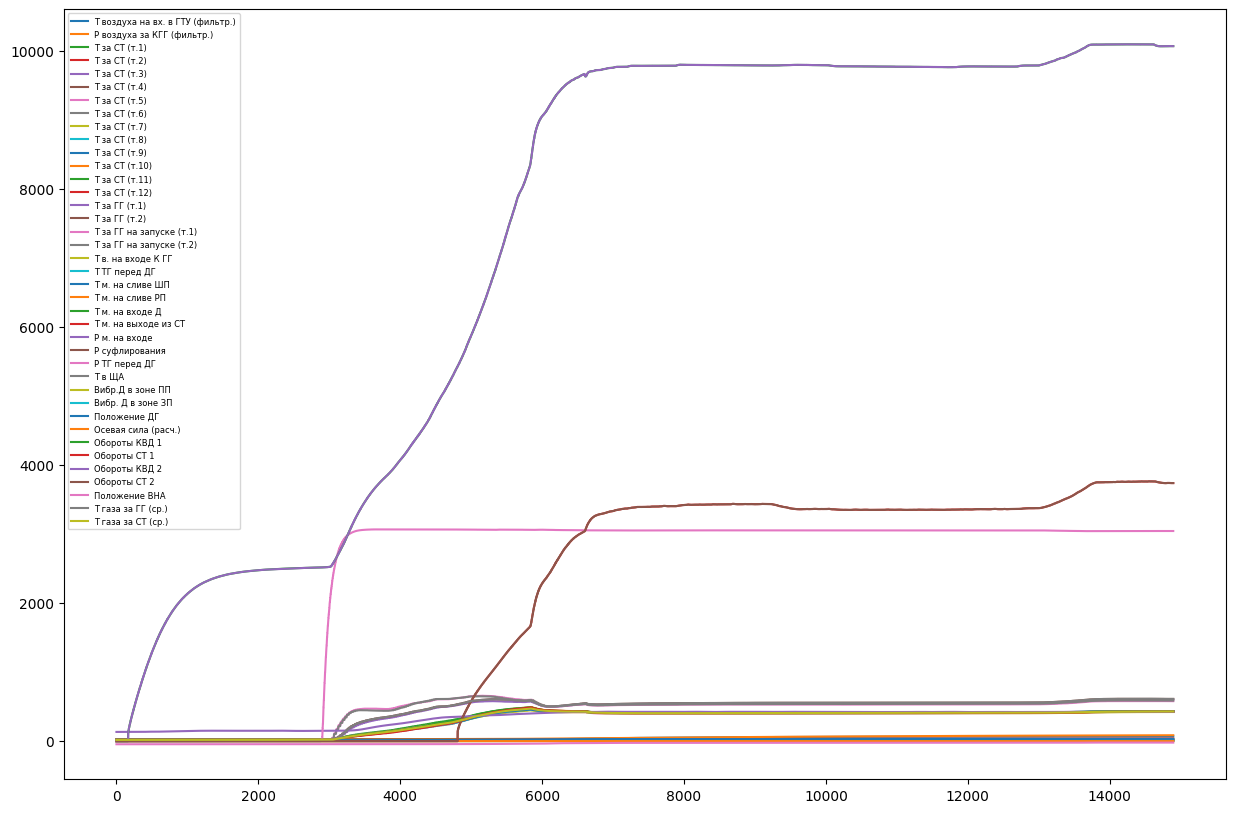

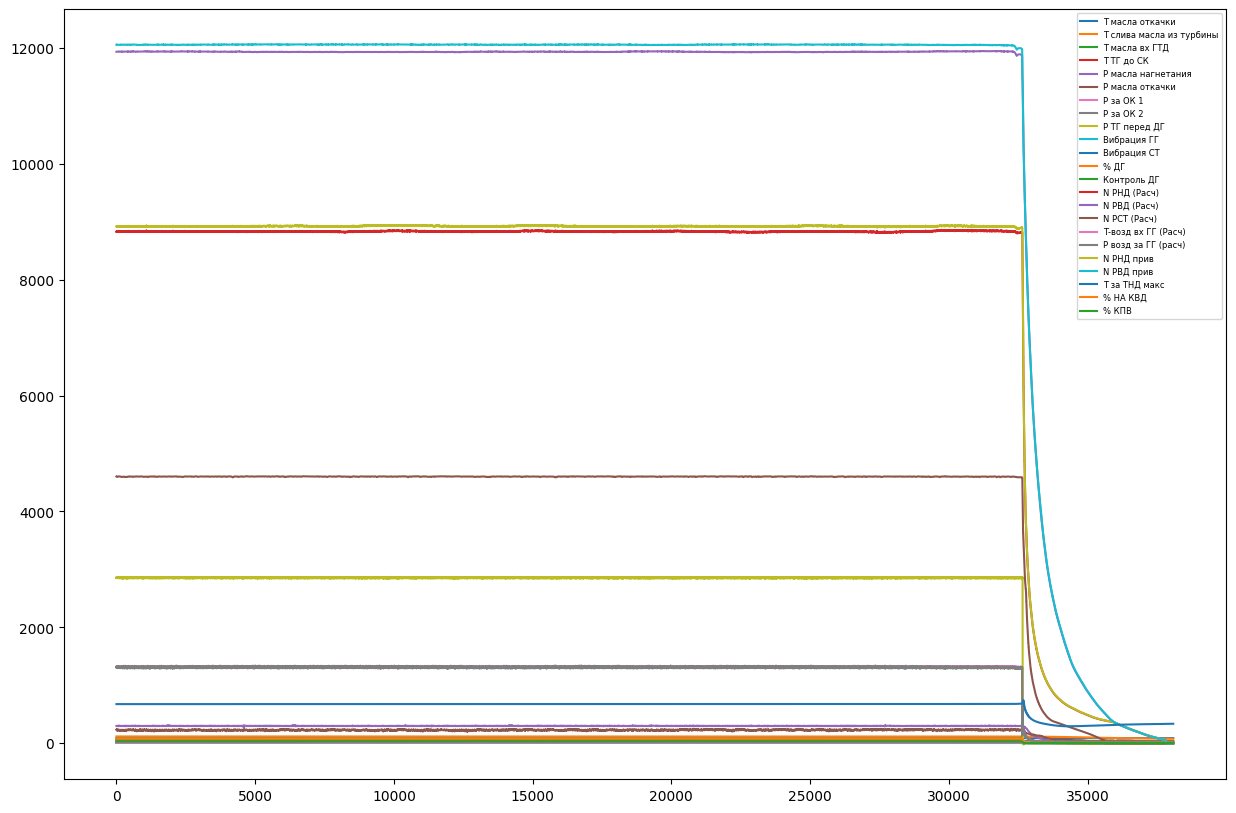

In [18]:
for df in dfs:
    df.plot(figsize=(15, 10))
    plt.legend(fontsize=6)
    plt.show()

In [19]:
all_series = sorted([pd.Series(df[column]) for df in dfs for column in df.columns[1:]], key=lambda x: x.name, reverse=True)

In [20]:
groups_of_series = {
    'freq': all_series[:10],
    'temp': all_series[10:60],
    'pres': all_series[60:74] + all_series[91:103] + all_series[113:115],
    'pos': all_series[74:82],
    'axis': all_series[82:83],
    'rev': all_series[83:87],
    'ctl': all_series[87:91],
    'vibr': all_series[103:113],
    'n': all_series[115:125],
    'perc': all_series[125:131],
}

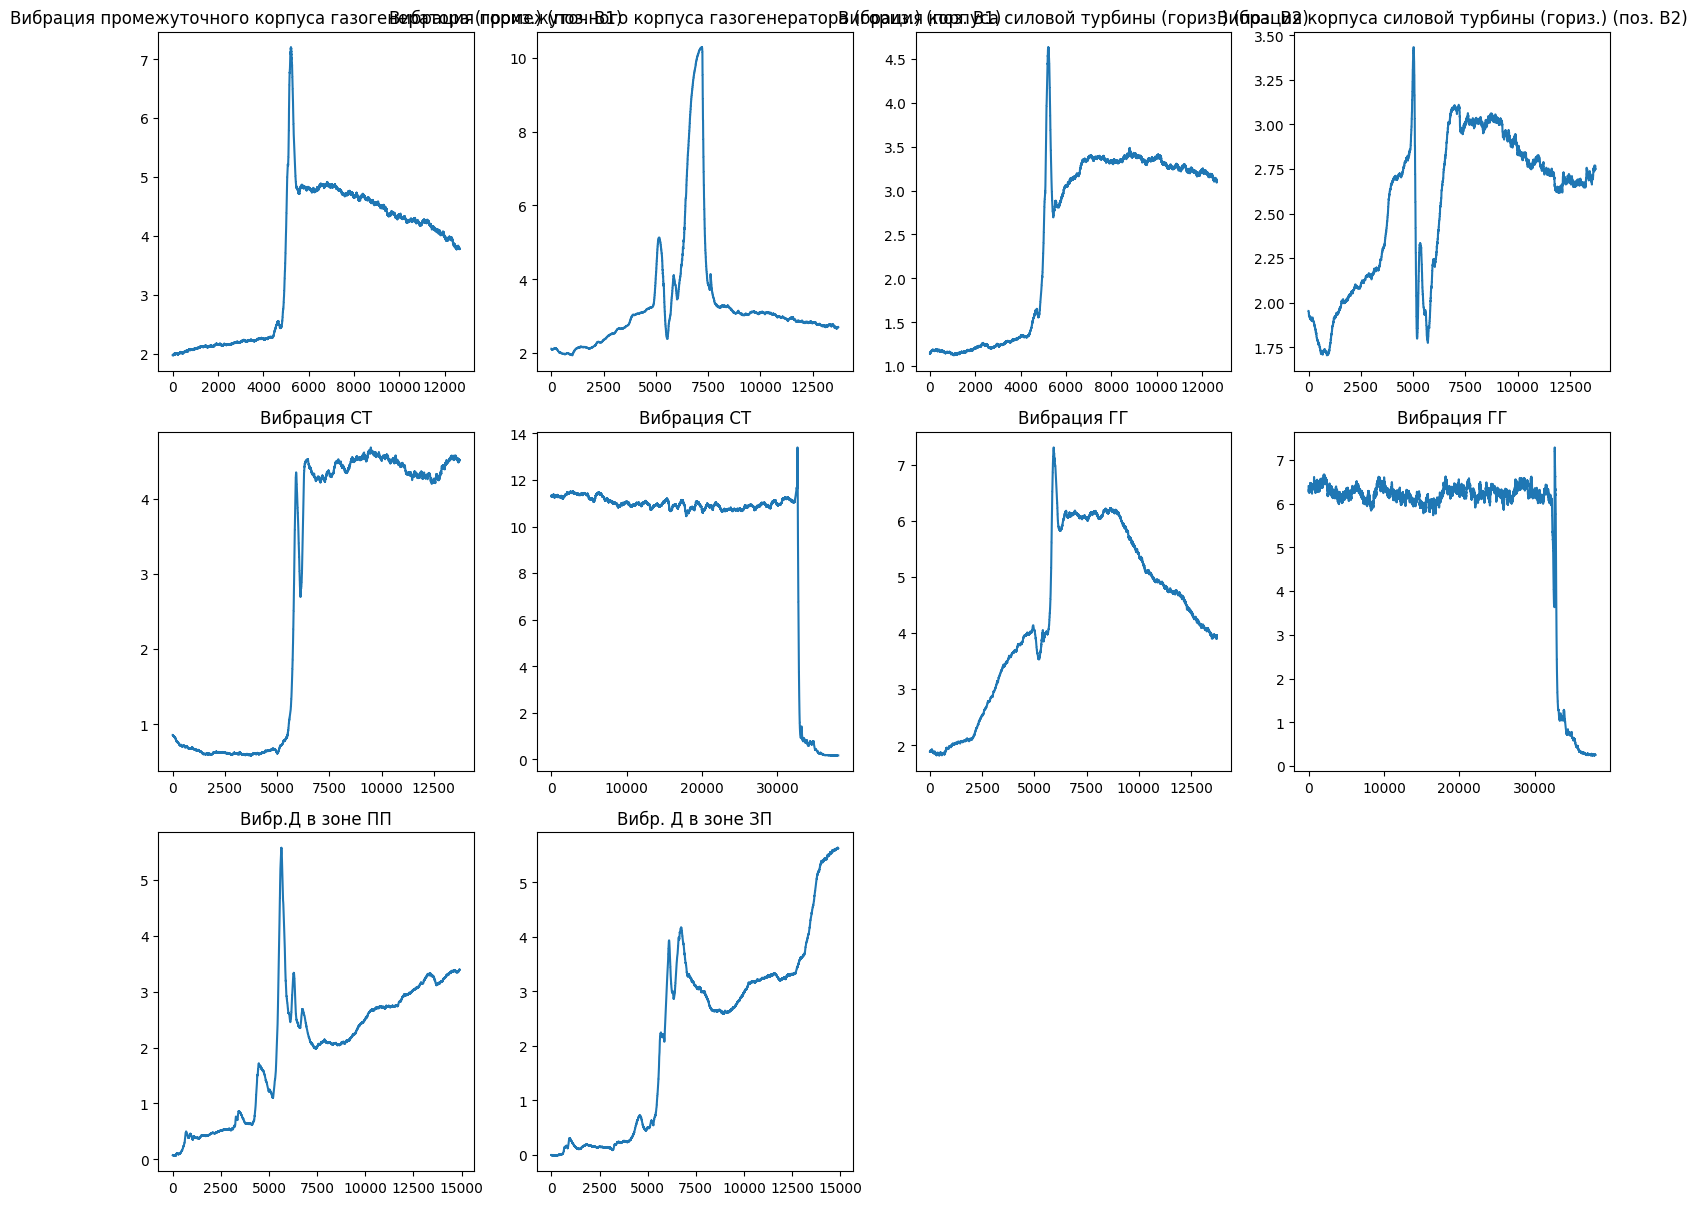

In [35]:
import matplotlib.pyplot as plt
import math

# Настройки сетки
n_series = len(all_series)
cols = 4  # Количество колонок
rows = math.ceil(n_series / cols) # Авто-расчет количества строк

fig, axes = plt.subplots(rows, cols, figsize=(15, rows * 4))
axes = axes.flatten() # Превращаем матрицу осей в плоский список

for i, series in enumerate(groups_of_series['vibr']): # ТУТ МОЖНО СМОТРЕТЬ ОТДЕЛЬНУЮ ГРУППУ
    series.plot(ax=axes[i])
    axes[i].set_title(series.name)

# Удаляем пустые графики, если количество серий не кратно колонкам
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [40]:
def add_random_point_anomalies(series, n_anomalies=3, anomaly_magnitude_factor=5, random_state=None):

    if random_state:
        np.random.seed(random_state)

    s = series.copy()
    std = s.std()
    if std == 0:
        std = 1.0

    # Выбираем случайные индексы для аномалий
    anomaly_indices = np.random.choice(s.index, size=n_anomalies, replace=False)

    # Создаём бинарную маску: 1 — аномалия, 0 — норма
    anomaly_mask = pd.Series(0, index=s.index, dtype=int)
    anomaly_mask.loc[anomaly_indices] = 1

    # Добавляем выбросы
    for idx in anomaly_indices:
        sign = np.random.choice([-1, 1])
        s.loc[idx] += sign * anomaly_magnitude_factor * std + np.random.normal(0, std * 0.1)

    return s, anomaly_mask  # теперь возвращаем маску вместо списка индексов

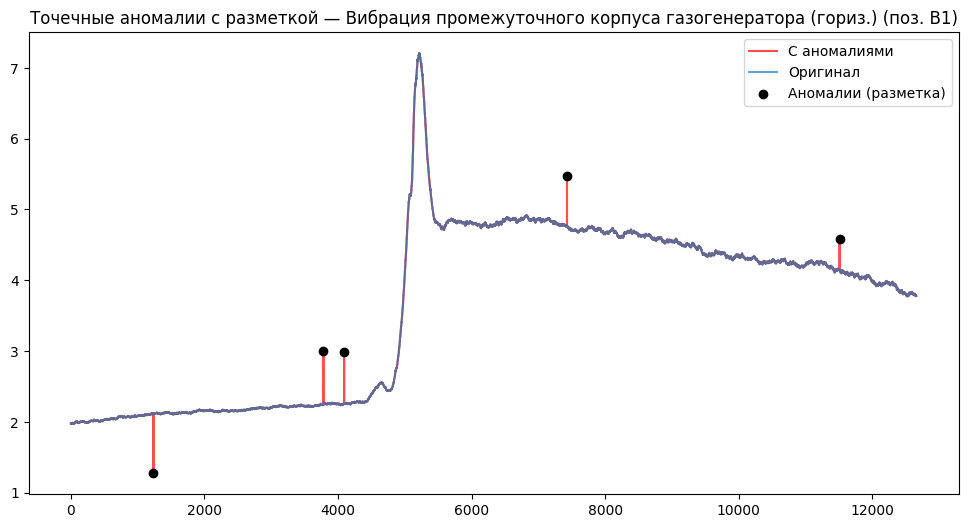

Пример разметки (первые 20 точек):
0     0
1     0
2     0
3     0
4     0
5     0
6     0
7     0
8     0
9     0
10    0
11    0
12    0
13    0
14    0
15    0
16    0
17    0
18    0
19    0
dtype: int64


In [50]:
# Пример: добавим аномалии к первому ряду из группы 'vibr'
sample_series = groups_of_series['vibr'][0].copy()

anomalous_series, anomaly_mask = add_random_point_anomalies(
    sample_series,
    n_anomalies=5,
    anomaly_magnitude_factor=.5,
    random_state=42
)

# Визуализация
plt.figure(figsize=(12, 6))
anomalous_series.plot(label='С аномалиями', color='red', alpha=0.7)
sample_series.plot(label='Оригинал', alpha=0.7)
# Отмечаем аномалии чёрными точками
anomalies_detected = anomalous_series[anomaly_mask == 1]
plt.scatter(anomalies_detected.index, anomalies_detected.values, color='black', zorder=5, label='Аномалии (разметка)')
plt.title(f"Точечные аномалии с разметкой — {sample_series.name}")
plt.legend()
plt.show()

# Показать первые 20 значений маски
print("Пример разметки (первые 20 точек):")
print(anomaly_mask.head(20))

In [38]:
def add_drifting_anomaly(series, drift_length=20, drift_magnitude_factor=3, noise_level=0.1, random_state=None):

    if random_state:
        np.random.seed(random_state)

    s = series.copy()
    std = s.std()
    if std == 0:
        std = 1.0

    # Определяем диапазон, где можно разместить дрейф
    start_idx = np.random.randint(0, len(s) - drift_length - 1)
    end_idx = start_idx + drift_length

    # Направление дрейфа: вверх или вниз
    direction = np.random.choice([-1, 1])

    # Генерируем плавный дрейф (линейный или экспоненциальный)
    drift = np.linspace(0, direction * drift_magnitude_factor * std, drift_length)
    drift += np.random.normal(0, std * noise_level, drift_length)  # добавляем шум

    # Применяем дрейф
    s.iloc[start_idx:end_idx] += drift

    return s, (start_idx, end_idx)

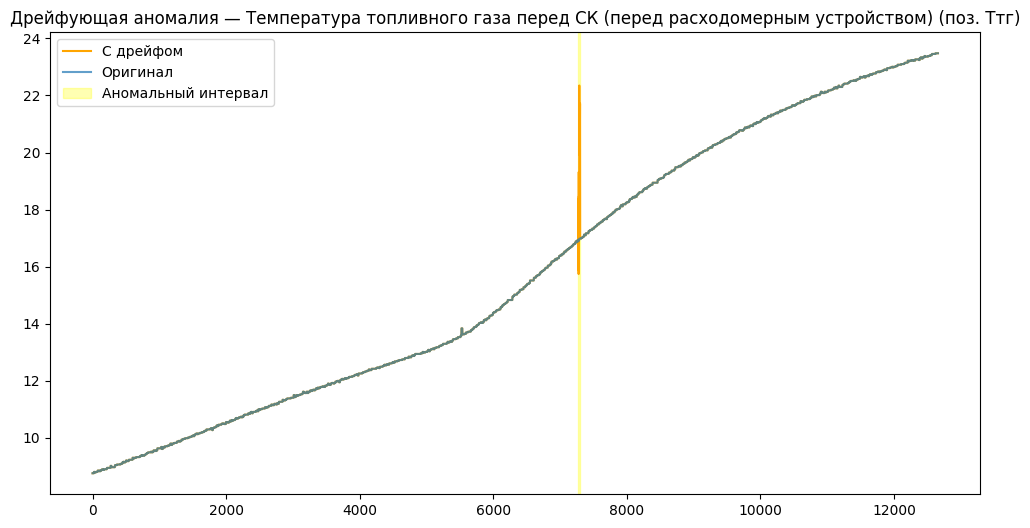

In [43]:
# Пример: добавим дрейф к первому ряду 'temp'
sample_series = groups_of_series['temp'][0].copy()

drifted_series, (start, end) = add_drifting_anomaly(
    sample_series,
    drift_length=30,
    drift_magnitude_factor=4,
    noise_level=0.2,
    random_state=42
)

# Визуализация
plt.figure(figsize=(12, 6))
drifted_series.plot(label='С дрейфом', color='orange')
sample_series.plot(label='Оригинал', alpha=0.7)
plt.axvspan(start, end, color='yellow', alpha=0.3, label='Аномальный интервал')
plt.title(f"Дрейфующая аномалия — {sample_series.name}")
plt.legend()
plt.show()